In [ ]:
import logging
import os
import pickle
import random
import sys
from os.path import join

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# from hyperopt import fmin, tpe, hp, Trials, rand
import xgboost as xgb
from sklearn.metrics import matthews_corrcoef, roc_auc_score
from sklearn.model_selection import KFold

sys.path.append("./additional_code")
# from data_preprocessing import *
CURRENT_DIR = os.getcwd()
print(CURRENT_DIR)
our_data = CURRENT_DIR + "/../data/our_data/"

/home/hanxd/Repositories/ESP/our_codes


In [ ]:
df = pd.read_pickle(join(CURRENT_DIR, "..", "data", "our_data", "5foldsdata.pkl"))

In [ ]:
df.to_csv(join(CURRENT_DIR, "..", "data", "our_data", "5foldsdata.csv"))

In [ ]:
df1know = df[df["Binding"] == 1]["scores"]
df1unknow = df[df["Binding"] == 0]["scores"]

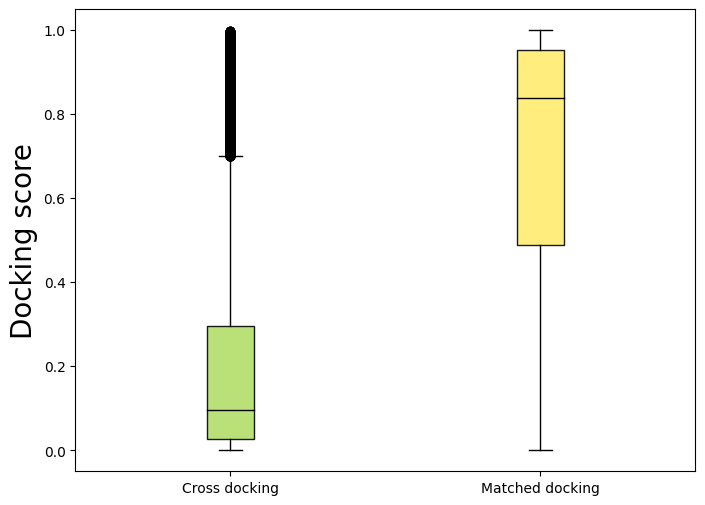

In [ ]:
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

plt.figure(figsize=(8, 6))
cmap = cm.Set3
box = plt.boxplot([df1unknow, df1know], patch_artist=True)

for i, patch in enumerate(box["boxes"]):
    patch.set_facecolor(cmap((i + 1) / (2)))
    patch.set_alpha(0.9)

for median in box["medians"]:
    median.set_color("black")
plt.ylabel("Docking score", fontsize=20)
plt.xticks([1, 2], ["Cross docking", "Matched docking"])
plt.show()

In [ ]:
df1ranking = df[df["Binding"] == 1]["ranking"] / df["ranking"].max()

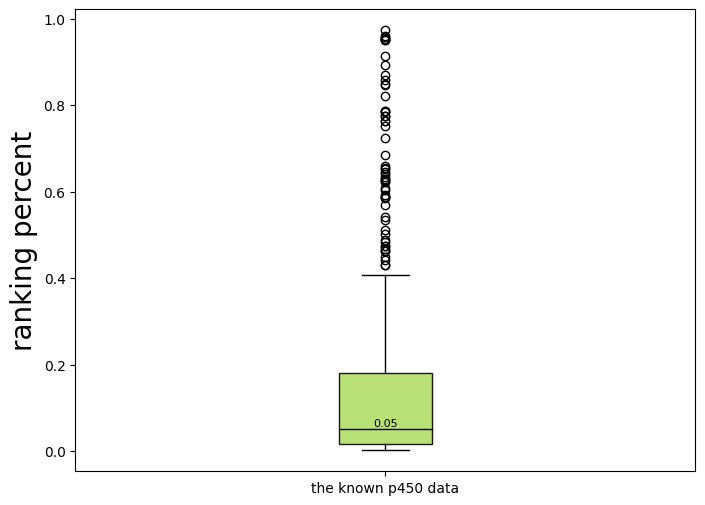

In [ ]:
plt.figure(figsize=(8, 6))
cmap = cm.Set3
box = plt.boxplot(df1ranking, patch_artist=True)

for i, patch in enumerate(box["boxes"]):
    patch.set_facecolor(cmap((i + 1) / (2)))
    patch.set_alpha(0.9)


median = np.median(df1ranking)
plt.text(1, median, f"{median:.2f}", ha="center", va="bottom", fontsize=8)


for median in box["medians"]:
    median.set_color("black")
plt.ylabel("ranking percent", fontsize=20)
plt.xticks([1], ["the known p450 data"])
plt.show()

In [8]:
np.median(df1ranking)

0.05222437137330754

In [9]:
df

,enzyme,substrate,Binding,ESM1b,ECFP,scores,ranking
101776,CYP710A11,5-dehydroepisterol,0.0,"[-0.09582178294658661, 0.22791782021522522, -0...",0100100010000000000000000000010001001100000000...,0.916981,1
119551,CYP90B27,5-dehydroepisterol,0.0,"[-0.11578469723463058, 0.21517443656921387, 0....",0100100010000000000000000000010001001100000000...,0.874565,2
118840,CYP88L2,5-dehydroepisterol,0.0,"[-0.05455482751131058, 0.2645743191242218, 0.0...",0100100010000000000000000000010001001100000000...,0.868432,3
97984,CYP51H10,5-dehydroepisterol,0.0,"[-0.11576467752456665, 0.21588265895843506, 0....",0100100010000000000000000000010001001100000000...,0.835169,4
70255,CYP90D2,5-dehydroepisterol,0.0,"[-0.12136734277009964, 0.25334739685058594, 0....",0100100010000000000000000000010001001100000000...,0.824578,5
...,...,...,...,...,...,...,...
3541,CYP719A2,triptophenolide,0.0,"[-0.002945970743894577, 0.18893994390964508, 0...",0100000000000000000000000000000001001000000000...,0.002282,513
35536,CYP74A301,triptophenolide,0.0,"[-0.15476122498512268, 0.25430721044540405, -0...",0100000000000000000000000000000001001000000000...,0.002129,514
11362,CYP74A2,triptophenolide,0.0,"[-0.0976535752415657, 0.24440722167491913, -0....",0100000000000000000000000000000001001000000000...,0.001803,515
11836,CYP74B2,triptophenolide,0.0,"[-0.0925406962633133, 0.22438989579677582, 0.0...",0100000000000000000000000000000001001000000000...,0.001196,516


In [ ]:
df[df["enzyme"] == "CYP76AH68"]

,enzyme,substrate,Binding,ESM1b,ECFP,scores,ranking
63382,CYP76AH68,5-dehydroepisterol,0.0,"[-0.06508982926607132, 0.13588164746761322, -0...",0100100010000000000000000000010001001100000000...,0.059264,253
63483,CYP76AH68,AAM,0.0,"[-0.06508982926607132, 0.13588164746761322, -0...",0000000000000000000000000000000101001000000000...,0.590768,108
63338,CYP76AH68,ABA,0.0,"[-0.06508982926607132, 0.13588164746761322, -0...",0000100000000000000000000000000001001000000000...,0.535482,26
63495,CYP76AH68,ABI,0.0,"[-0.06508982926607132, 0.13588164746761322, -0...",1100100000000000000000000000000001001000000000...,0.493765,34
63321,CYP76AH68,ABS,0.0,"[-0.06508982926607132, 0.13588164746761322, -0...",0000000000000000000000000000000101001000000000...,0.034139,454
...,...,...,...,...,...,...,...
63506,CYP76AH68,kenA1,0.0,"[-0.06508982926607132, 0.13588164746761322, -0...",0000100000000000000000000000000001001000000000...,0.246677,176
63354,CYP76AH68,manool,0.0,"[-0.06508982926607132, 0.13588164746761322, -0...",0000100000000000000000000000000001011000000000...,0.777477,27
63462,CYP76AH68,psoralen,0.0,"[-0.06508982926607132, 0.13588164746761322, -0...",0000000000000000000000000000000000000000000000...,0.100996,230
63288,CYP76AH68,resorcinol,0.0,"[-0.06508982926607132, 0.13588164746761322, -0...",0000000000000000000000000000000001000010000000...,0.369486,37


In [ ]:
df[["enzyme", "substrate", "Binding", "scores", "ranking"]].to_csv(
    join(CURRENT_DIR, "..", "data", "our_data", "5foldsdata_little.csv")
)